# Hospital Readmission Risk Analysis
**Portfolio project: Healthcare Data Analyst track**

**Dataset:** Diabetes 130-US Hospitals for Years 1999–2008 (real, publicly available, ~101,766 patient encounters)
Source: UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/296/diabetes-130-us-hospitals-for-years-1999-2008

**Business question:** Which patients and conditions are driving 30-day hospital readmissions, and what should the hospital do about it?

**Why it matters:** US hospitals are financially penalized (CMS Hospital Readmissions Reduction Program) for high readmission rates, so reducing avoidable readmissions is a real, budget relevant problem not a toy exercise.

In [2]:
# 1. Setup and imports
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")
pd.set_option('display.max_columns', 100)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 2. Upload the dataset (tap 'Choose Files' when this runs)
from google.colab import files
uploaded = files.upload()  # select diabetic_data.csv

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(df.shape)
df.head()

Saving diabetic_data.csv to diabetic_data.csv
(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Data cleaning
The dataset uses `?` for missing values, and a few columns (`weight`, `payer_code`, `medical_specialty`) are missing for most rows a good, honest talking point in your case study about real world data quality.

In [5]:
# Replace '?' with NaN and check missingness
df = df.replace('?', np.nan)
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print(missing_pct.head(10))

# Drop columns that are missing for the large majority of rows
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
df_clean = df.drop(columns=cols_to_drop)

# Create a clear binary target: readmitted within 30 days or not
df_clean['readmit_30d'] = (df_clean['readmitted'] == '<30').astype(int)

print("Dropped columns:", cols_to_drop)
print("Readmission rate (<30 days):", df_clean['readmit_30d'].mean().round(3))

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
patient_nbr           0.000000
dtype: float64
Dropped columns: ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty']
Readmission rate (<30 days): 0.112


## 4. SQL analysis
Loading the cleaned data into an in-memory SQLite database so you can show real SQL queries, not just pandas.

In [6]:
conn = sqlite3.connect(':memory:')
df_clean.to_sql('encounters', conn, index=False, if_exists='replace')

# Readmission rate by age group
q1 = """
SELECT age,
       COUNT(*) AS total_encounters,
       SUM(readmit_30d) AS readmissions,
       ROUND(100.0 * SUM(readmit_30d) / COUNT(*), 2) AS readmit_rate_pct
FROM encounters
GROUP BY age
ORDER BY readmit_rate_pct DESC;
"""
age_readmit = pd.read_sql(q1, conn)
age_readmit

,age,total_encounters,readmissions,readmit_rate_pct
0,[20-30),1657,236,14.24
1,[80-90),17197,2078,12.08
2,[70-80),26068,3069,11.77
3,[30-40),3775,424,11.23
4,[60-70),22483,2502,11.13
5,[90-100),2793,310,11.10
6,[40-50),9685,1027,10.60
7,[50-60),17256,1668,9.67
8,[10-20),691,40,5.79
9,[0-10),161,3,1.86


In [7]:
# Readmission rate by number of prior inpatient visits
q2 = """
SELECT number_inpatient,
       COUNT(*) AS total_encounters,
       ROUND(100.0 * SUM(readmit_30d) / COUNT(*), 2) AS readmit_rate_pct
FROM encounters
GROUP BY number_inpatient
ORDER BY number_inpatient;
"""
prior_visits_readmit = pd.read_sql(q2, conn)
prior_visits_readmit

,number_inpatient,total_encounters,readmit_rate_pct
0,0,67630,8.44
1,1,19521,12.92
2,2,7566,17.43
3,3,3411,20.29
4,4,1622,23.61
5,5,812,31.40
6,6,480,34.58
7,7,268,35.45
8,8,151,44.37
9,9,111,42.34


In [8]:
# Average time in hospital: readmitted vs not
q3 = """
SELECT readmit_30d,
       ROUND(AVG(time_in_hospital), 2) AS avg_days_in_hospital,
       ROUND(AVG(num_medications), 2) AS avg_num_medications,
       COUNT(*) AS total_encounters
FROM encounters
GROUP BY readmit_30d;
"""
stay_comparison = pd.read_sql(q3, conn)
stay_comparison

,readmit_30d,avg_days_in_hospital,avg_num_medications,total_encounters
0,0,4.35,15.91,90409
1,1,4.77,16.90,11357


## 5. Exploratory visualizations

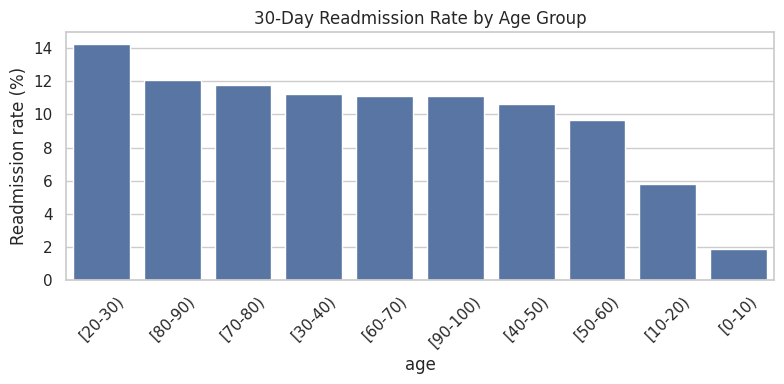

In [9]:
plt.figure(figsize=(8,4))
sns.barplot(data=age_readmit, x='age', y='readmit_rate_pct', color='#4C72B0')
plt.xticks(rotation=45)
plt.title('30-Day Readmission Rate by Age Group')
plt.ylabel('Readmission rate (%)')
plt.tight_layout()
plt.savefig('readmission_by_age.png', dpi=150)
plt.show()

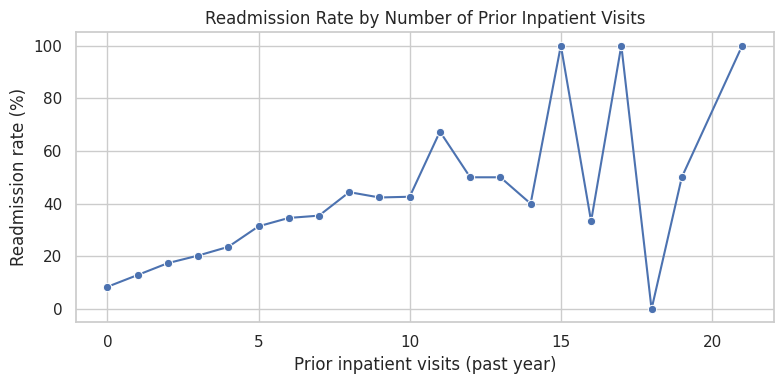

In [10]:
plt.figure(figsize=(8,4))
sns.lineplot(data=prior_visits_readmit, x='number_inpatient', y='readmit_rate_pct', marker='o')
plt.title('Readmission Rate by Number of Prior Inpatient Visits')
plt.xlabel('Prior inpatient visits (past year)')
plt.ylabel('Readmission rate (%)')
plt.tight_layout()
plt.savefig('readmission_by_prior_visits.png', dpi=150)
plt.show()

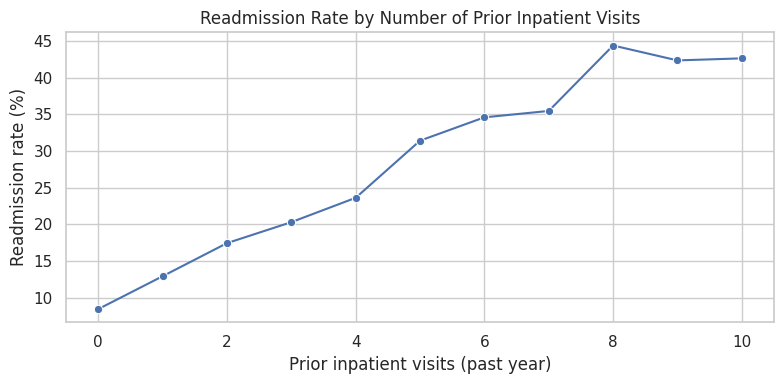

In [11]:
# Filter to prior-visit counts with reliable sample sizes
prior_visits_readmit_clean = prior_visits_readmit[prior_visits_readmit['number_inpatient'] <= 10]

plt.figure(figsize=(8,4))
sns.lineplot(data=prior_visits_readmit_clean, x='number_inpatient', y='readmit_rate_pct', marker='o')
plt.title('Readmission Rate by Number of Prior Inpatient Visits')
plt.xlabel('Prior inpatient visits (past year)')
plt.ylabel('Readmission rate (%)')
plt.tight_layout()
plt.savefig('readmission_by_prior_visits_clean.png', dpi=150)
plt.show()

## 6. Light predictive model: readmission risk flag
This is the piece that shows you understand the analytical foundation an automated/agentic monitoring system would sit on top of, not just descriptive reporting.

In [ ]:
model_df = df_clean.copy()

features = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']

# Encode age (ordinal categories like '[70-80)') as a label
le = LabelEncoder()
model_df['age_enc'] = le.fit_transform(model_df['age'])
features = ['age_enc' if f == 'age' else f for f in features]

X = model_df[features]
y = model_df['readmit_30d']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

coef_df = pd.DataFrame({'feature': features, 'coefficient': clf.coef_[0]}).sort_values('coefficient', ascending=False)
coef_df

Accuracy: 0.682
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     18083
           1       0.17      0.48      0.25      2271

    accuracy                           0.68     20354
   macro avg       0.54      0.60      0.53     20354
weighted avg       0.83      0.68      0.74     20354



,feature,coefficient
7,number_inpatient,0.294784
6,number_emergency,0.060674
0,age_enc,0.043980
8,number_diagnoses,0.043868
1,time_in_hospital,0.026344
4,num_medications,0.007065
2,num_lab_procedures,0.000126
5,number_outpatient,-0.005788
3,num_procedures,-0.024098


## 7. Export summary tables for your Looker Studio dashboard

In [ ]:
age_readmit.to_csv('summary_readmit_by_age.csv', index=False)
prior_visits_readmit.to_csv('summary_readmit_by_prior_visits.csv', index=False)
stay_comparison.to_csv('summary_stay_comparison.csv', index=False)

# Download these to upload into a Google Sheet, then connect that Sheet to Looker Studio
from google.colab import files
files.download('summary_readmit_by_age.csv')
files.download('summary_readmit_by_prior_visits.csv')
files.download('summary_stay_comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Case study notes

- **Problem:** US hospitals are financially penalized for high 30-day readmission rates. This project identifies which patients are most likely to be readmitted so hospitals can target interventions before discharge.

- **What was analyzed:** 101,766 real inpatient diabetes encounters (1999–2008, 130 US hospitals). Cleaned the data (removed columns missing for 40%+ of records: weight, max_glu_serum, A1Cresult, medical_specialty), then analyzed readmission patterns using SQL queries and a logistic regression model.

- **Key findings:**
  - Overall 30-day readmission rate: 11.2%.
  - Number of prior inpatient admissions is the strongest risk driver: readmission rate rises from 8.4% (0 prior admissions) to 20.3% (3 prior admissions) to over 44% (8+ prior admissions).
  - Readmitted patients have slightly longer hospital stays (4.77 vs 4.35 days) and take more medications (16.9 vs 15.9) than non-readmitted patients.
  - A baseline logistic regression model reached 68.2% accuracy and correctly flagged 48% of actual readmissions (recall), confirming prior inpatient visits as the dominant predictive feature.

- **Recommendation:** Prioritize discharge follow-up (phone check-ins, home health visits) for patients with 2+ prior inpatient admissions in the past year — this group's readmission risk is 2–4x the baseline rate, making it the highest-leverage group for intervention.

- **Evidence produced:** SQL queries (age/prior-visit/stay breakdowns), 2 visualizations, logistic regression risk model, 3 exported summary CSVs for dashboarding.130)th 2+ prior admissions
- **Evidence produced:** SQL queries, charts, logistic regression model, exported dashboard data



Done and Analyzed by Oluwatoyin oloruntoba.